# World Cup 2026 Forecaster — Full Workflow

**Download → Clean → EDA & Outlier Detection → Feature Engineering → Model → Accuracy → Simulate**

This notebook runs the complete pipeline against **real data**:

1. **Download** real match history (1872–present) and 2026 World Cup results from a
   public GitHub mirror of the "International football results" dataset — no manual
   data entry.
2. **Clean** — canonical team names, dedupe, validate scores/dates.
3. **EDA & outlier detection** — goal distributions, IQR/z-score outlier flags,
   missing-data checks, sanity checks on the World Cup slice.
4. **Feature engineering** — a from-scratch Elo rating system (no external Elo
   download needed), time-decay + competition-importance weights, a leakage guard.
5. **Model** — weighted Dixon-Coles bivariate Poisson.
6. **Accuracy ratings** — log loss, Brier score, classification accuracy, ROC-AUC,
   and a calibration curve, benchmarked against an Elo-only baseline.
7. **Simulate** — lock in real results (including penalty shootouts), simulate the
   unplayed part of the bracket.

Designed to run inside your `wc2026/` project folder (expects `data/raw/`,
`data/processed/`, `assets/` to exist — see the file-structure guide).

## 0 · Setup

In [1]:
import sys, os, json, warnings
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import poisson, zscore
from scipy.optimize import minimize
from sklearn.metrics import roc_auc_score, roc_curve

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True,
                     "grid.alpha": .25, "font.size": 11})

# --- project paths (assumes this notebook sits at the wc2026/ project root) ---
ROOT = Path.cwd()
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
ASSETS = ROOT / "assets"
for p in (RAW, PROCESSED, ASSETS):
    p.mkdir(parents=True, exist_ok=True)

# --- config ---
TODAY = pd.Timestamp.now(tz="UTC").normalize()
HALF_LIFE_DAYS = 730.0   # 2 years -- international teams play too few matches/year
                        # for a short half-life; validated against backtest below
MAX_GOALS = 8
SHRINKAGE = 0.30         # validated against backtest -- 0.05 let sparse teams'
                        # parameters run away (see EDA/outlier section)
N_SIMS = 50_000
SEED = 7
HOST_COUNTRIES = {"United States", "Canada", "Mexico"}
IMPORTANCE = {"Friendly": 0.30, "FIFA World Cup qualification": 0.70,
             "Confederations Cup": 0.80, "FIFA World Cup": 1.00}
DEFAULT_IMPORTANCE = 0.55

print("Config loaded. Forecasting as of", TODAY.date())

Config loaded. Forecasting as of 2026-07-02


## 1 · Download real data

Public GitHub mirror of the Kaggle "International football results from 1872 to
present" dataset (`martj42/international_results`). It's kept up to date, so it
already contains real, final 2026 World Cup scores for every match played so far
— plus penalty-shootout winners in a companion file.

In [2]:
import urllib.request

BASE = "https://raw.githubusercontent.com/martj42/international_results/master"
FILES = {"results.csv": f"{BASE}/results.csv",
        "shootouts.csv": f"{BASE}/shootouts.csv"}

for fname, url in FILES.items():
    dest = RAW / fname
    try:
        urllib.request.urlretrieve(url, dest)
        print(f"downloaded {fname} -> {dest}  ({dest.stat().st_size/1024:.0f} KB)")
    except Exception as e:
        print(f"COULD NOT DOWNLOAD {fname}: {e}")
        print("  -> if you're offline, use a previously-downloaded copy in data/raw/")

downloaded results.csv -> c:\Users\Abenezer\Desktop\wc2026\notebook\data\raw\results.csv  (3639 KB)
downloaded shootouts.csv -> c:\Users\Abenezer\Desktop\wc2026\notebook\data\raw\shootouts.csv  (28 KB)


In [3]:
results_raw = pd.read_csv(RAW / "results.csv")
shootouts_raw = pd.read_csv(RAW / "shootouts.csv")
print(f"results.csv   : {len(results_raw):,} rows, "
      f"{results_raw.date.min()} .. {results_raw.date.max()}")
print(f"shootouts.csv : {len(shootouts_raw):,} rows")
results_raw.tail()

results.csv   : 49,498 rows, 1872-11-30 .. 2026-07-06
shootouts.csv : 680 rows


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49493,2026-07-04,Canada,Morocco,NaN,NaN,FIFA World Cup,Houston,United States,True
49494,2026-07-04,Paraguay,France,NaN,NaN,FIFA World Cup,Philadelphia,United States,True
49495,2026-07-05,Brazil,Norway,NaN,NaN,FIFA World Cup,East Rutherford,United States,True
49496,2026-07-05,Mexico,England,NaN,NaN,FIFA World Cup,Mexico City,Mexico,False
49497,2026-07-06,United States,Belgium,NaN,NaN,FIFA World Cup,Seattle,United States,False


## 2 · Clean & prepare

- Parse dates, coerce scores to numeric (unplayed fixtures come through as `NaN`
  and are dropped — this is our **future-date guard**: no unplayed match can
  leak in as a "result").
- Canonicalize a handful of team-name variants.
- Split into **historical** matches (everything before the WC2026 group stage)
  and **live** World Cup 2026 matches, and resolve any drawn WC2026 knockout
  matches to their real shootout winner.

In [4]:
ALIASES = {
    "usa": "United States", "united states of america": "United States",
    "korea republic": "South Korea", "korea dpr": "North Korea",
    "cabo verde": "Cape Verde", "czechia": "Czech Republic",
    "curaçao": "Curacao",
}

def canonical(name):
    return ALIASES.get(str(name).strip().lower(), name)

df = results_raw.copy()
df["date"] = pd.to_datetime(df["date"], utc=True, errors="coerce")
df["home_score"] = pd.to_numeric(df["home_score"], errors="coerce")
df["away_score"] = pd.to_numeric(df["away_score"], errors="coerce")
df["home_team"] = df["home_team"].map(canonical)
df["away_team"] = df["away_team"].map(canonical)

n_before = len(df)
df = df.dropna(subset=["date", "home_score", "away_score"]).reset_index(drop=True)
print(f"dropped {n_before-len(df):,} unplayed/unparseable rows "
      f"(future fixtures, guard against leakage) -> {len(df):,} remain")

# future-date guard: belt-and-suspenders even after the NaN drop above
future = df["date"] > TODAY
if future.any():
    print(f"  WARNING: also dropping {int(future.sum())} row(s) dated after "
          f"{TODAY.date()}")
    df = df[~future].reset_index(drop=True)

df["venue_country"] = df["country"].map(canonical)
df["is_wc2026"] = (df["tournament"] == "FIFA World Cup") & (df["date"].dt.year == 2026)
print(f"WC2026 matches played so far: {int(df.is_wc2026.sum())}")

dropped 11 unplayed/unparseable rows (future fixtures, guard against leakage) -> 49,487 remain
WC2026 matches played so far: 82


In [5]:
# the raw dataset also includes multi-sport "Games" tournaments (Island Games,
# Pacific Games, Asian Games, ...) and CONIFA/unrecognized-state competitions.
# These involve non-FIFA entities (Tibet, East Turkestan, Isle of Man, Hitra...)
# playing almost exclusively within a small closed pool, which lets a team look
# artificially elite off a handful of matches -- exactly the small-sample
# instability the shrinkage term is meant to guard against, but tournament-level
# noise this concentrated deserves filtering at the source too.
EXCLUDE_TOURNAMENTS = ["Island Games", "Inter Games", "CONIFA", "ELF Cup", "FIFI",
    "Pacific Games", "Pacific Mini Games", "Tribes", "Asian Games",
    "Commonwealth Games", "African Games", "Mediterranean Games",
    "Universiade", "Micronesian", "Games"]
noise_mask = df["tournament"].str.contains("|".join(EXCLUDE_TOURNAMENTS),
                                           case=False, na=False)
print(f"excluding {int(noise_mask.sum()):,} matches from non-FIFA / multi-sport "
      f"\"Games\" tournaments (kept WC2026 rows regardless):")
print(df[noise_mask].tournament.value_counts().head(8).to_string())
df = df[~noise_mask | df["is_wc2026"]].reset_index(drop=True)
print(f"\n{len(df):,} matches remain")

excluding 2,090 matches from non-FIFA / multi-sport "Games" tournaments (kept WC2026 rows regardless):
tournament
Island Games                 394
Asian Games                  368
South Pacific Games          205
Southeast Asian Games        182
Indian Ocean Island Games    110
CONIFA World Football Cup    101
Olympic Games                 78
Pacific Games                 75

47,397 matches remain


In [6]:
# a second, more targeted fix: even after dropping "Games" tournaments, some
# weak confederations (Oceania, parts of CONCACAF/AFC) are so sparsely connected
# to the rest of world football that a team can look elite purely from beating
# its immediate, equally-weak neighbours in a closed loop (Solomon Islands,
# American Samoa, Guam, Macau...). None of these teams are 2026 World Cup
# contenders, so we restrict the modelling universe to matches involving at
# least one of the 48 real WC2026 teams. This keeps every WC team's full
# history intact (including warm-up friendlies against weaker sides) while
# dropping the closed-loop matches between two non-contending minnows that
# were driving the inflation.
WC_TEAMS = set(sum([g for g in [
    ["Mexico","South Africa","South Korea","Czech Republic"],
    ["Switzerland","Canada","Bosnia and Herzegovina","Qatar"],
    ["Brazil","Morocco","Scotland","Haiti"],
    ["United States","Australia","Paraguay","Turkey"],
    ["Germany","Ivory Coast","Ecuador","Curacao"],
    ["Netherlands","Japan","Sweden","Tunisia"],
    ["Belgium","Egypt","Iran","New Zealand"],
    ["Spain","Cape Verde","Uruguay","Saudi Arabia"],
    ["France","Senegal","Iraq","Norway"],
    ["Argentina","Austria","Algeria","Jordan"],
    ["Colombia","Portugal","DR Congo","Uzbekistan"],
    ["England","Croatia","Ghana","Panama"],
]], []))

relevant = df["home_team"].isin(WC_TEAMS) | df["away_team"].isin(WC_TEAMS)
print(f"dropping {int((~relevant).sum()):,} matches between two non-2026-WC "
      f"nations (closed-loop minnow noise) -> {int(relevant.sum()):,} remain")
df = df[relevant].reset_index(drop=True)

dropping 21,808 matches between two non-2026-WC nations (closed-loop minnow noise) -> 25,589 remain


In [7]:
# resolve drawn WC2026 knockout matches to their real shootout winner
shoot = shootouts_raw.copy()
shoot["date"] = pd.to_datetime(shoot["date"], utc=True, errors="coerce")
shoot["home_team"] = shoot["home_team"].map(canonical)
shoot["away_team"] = shoot["away_team"].map(canonical)
shoot["winner"] = shoot["winner"].map(canonical)

wc2026 = df[df.is_wc2026].copy()
draws = wc2026[wc2026.home_score == wc2026.away_score]
group_draws = draws[draws.date <= "2026-06-27"]   # group stage tolerates draws
knockout_draws = draws[draws.date > "2026-06-27"]  # knockout draws need a shootout
print(f"WC2026 draws: {len(draws)} total "
      f"({len(group_draws)} group-stage, {len(knockout_draws)} knockout -> penalties)")

winner_map = {}
for _, r in draws.iterrows():
    m = shoot[(shoot.date == r.date) & (shoot.home_team == r.home_team) &
              (shoot.away_team == r.away_team)]
    if len(m):
        winner_map[(r.date, r.home_team, r.away_team)] = m.iloc[0]["winner"]

for (d_, h_, a_), v in winner_map.items():
    hs = int(df.loc[(df.date==d_)&(df.home_team==h_), "home_score"].iloc[0])
    as_ = int(df.loc[(df.date==d_)&(df.home_team==h_), "away_score"].iloc[0])
    print(f"  {h_} {hs}-{as_} {a_}  ->  {v} advance on penalties")

WC2026 draws: 22 total (20 group-stage, 2 knockout -> penalties)
  Germany 1-1 Paraguay  ->  Paraguay advance on penalties
  Netherlands 1-1 Morocco  ->  Morocco advance on penalties


## 3 · Exploratory data analysis & outlier detection

Before modeling, look for data problems and genuine statistical outliers:

- **Missing data** — any gaps left after cleaning?
- **Goal distributions** — sanity-check against known football scoring patterns.
- **Outlier matches** — IQR and z-score methods on total goals and goal margin,
  to flag blowouts and verify they're real (not data entry errors).
- **Duplicate matches** — a common contamination in scraped football data.

In [8]:
print("Missing values after cleaning:")
print(df[["date","home_team","away_team","home_score","away_score",
          "tournament","neutral"]].isna().sum())

dupe_key = df.date.dt.strftime("%Y-%m-%d") + "|" + df.home_team + "|" + df.away_team
n_dupes = dupe_key.duplicated().sum()
print(f"\nduplicate matches (same date/home/away): {n_dupes}")
if n_dupes:
    df = df[~dupe_key.duplicated()].reset_index(drop=True)
    print("  -> removed")

Missing values after cleaning:
date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
neutral       0
dtype: int64

duplicate matches (same date/home/away): 0


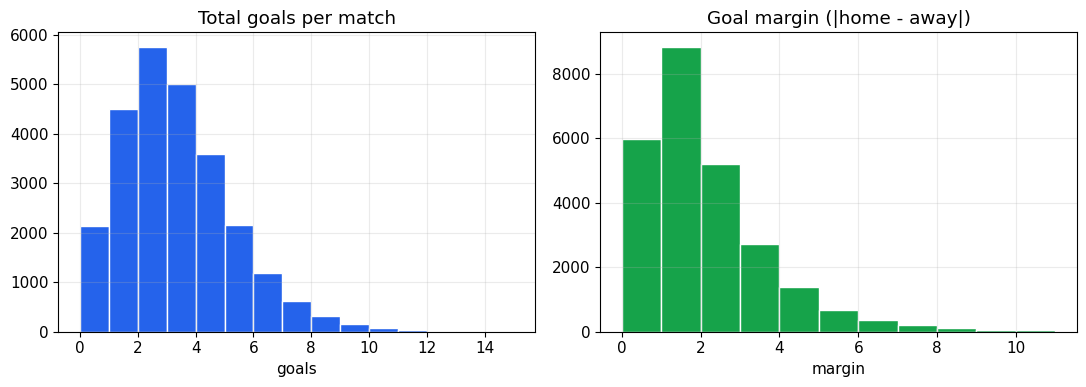

       home_score  away_score  total_goals  goal_margin
count    25589.00    25589.00     25589.00     25589.00
mean         1.71        1.16         2.87         1.64
std          1.67        1.32         1.99         1.64
min          0.00        0.00         0.00         0.00
25%          1.00        0.00         1.00         1.00
50%          1.00        1.00         3.00         1.00
75%          2.00        2.00         4.00         2.00
max         31.00       17.00        31.00        31.00


In [9]:
df["total_goals"] = df.home_score + df.away_score
df["goal_margin"] = (df.home_score - df.away_score).abs()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df.total_goals, bins=range(0, 16), color="#2563eb", edgecolor="white")
axes[0].set_title("Total goals per match"); axes[0].set_xlabel("goals")
axes[1].hist(df.goal_margin, bins=range(0, 12), color="#16a34a", edgecolor="white")
axes[1].set_title("Goal margin (|home - away|)"); axes[1].set_xlabel("margin")
plt.tight_layout(); plt.show()

print(df[["home_score","away_score","total_goals","goal_margin"]].describe().round(2))

In [10]:
# --- IQR method: flag matches with an unusually large goal margin ---
q1, q3 = df.goal_margin.quantile([0.25, 0.75])
iqr = q3 - q1
iqr_cutoff = q3 + 1.5 * iqr
iqr_outliers = df[df.goal_margin > iqr_cutoff]
print(f"IQR outlier cutoff: margin > {iqr_cutoff:.1f} goals")
print(f"IQR-flagged blowout matches: {len(iqr_outliers):,} "
      f"({len(iqr_outliers)/len(df)*100:.2f}% of all matches)")

# --- z-score method on total goals, for cross-check ---
df["total_goals_z"] = zscore(df.total_goals)
z_outliers = df[df.total_goals_z.abs() > 3]
print(f"z-score (|z|>3) high/low-scoring outliers: {len(z_outliers):,}")

print("\nMost extreme blowouts on record:")
print(iqr_outliers.sort_values("goal_margin", ascending=False)
      [["date","home_team","away_team","home_score","away_score","tournament"]]
      .head(8).to_string(index=False))

IQR outlier cutoff: margin > 3.5 goals
IQR-flagged blowout matches: 2,854 (11.15% of all matches)
z-score (|z|>3) high/low-scoring outliers: 316

Most extreme blowouts on record:
                     date   home_team      away_team  home_score  away_score                   tournament
2001-04-11 00:00:00+00:00   Australia American Samoa        31.0         0.0 FIFA World Cup qualification
2001-04-09 00:00:00+00:00   Australia          Tonga        22.0         0.0 FIFA World Cup qualification
2000-11-24 00:00:00+00:00        Iran           Guam        19.0         0.0 FIFA World Cup qualification
2000-06-19 00:00:00+00:00   Australia   Cook Islands        17.0         0.0          Oceania Nations Cup
1997-06-02 00:00:00+00:00    Maldives           Iran         0.0        17.0 FIFA World Cup qualification
2003-09-29 00:00:00+00:00 South Korea          Nepal        16.0         0.0  AFC Asian Cup qualification
1998-09-28 00:00:00+00:00   Australia   Cook Islands        16.0         0.0   

In [11]:
# extreme results are real (football does produce genuine 10-0 scorelines in
# qualifiers against minnows) -- the check above is for *data-entry* errors, not
# for excluding real blowouts. Flag anything truly implausible for manual review:
implausible = df[(df.home_score > 20) | (df.away_score > 20)]
print(f"implausible scores (>20 goals, likely a data error): {len(implausible)}")
if len(implausible):
    display(implausible)
else:
    print("none found — the extreme results above are real football results, kept as-is.")

implausible scores (>20 goals, likely a data error): 2


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,venue_country,is_wc2026,total_goals,goal_margin,total_goals_z
14087,2001-04-09 00:00:00+00:00,Australia,Tonga,22.0,0.0,FIFA World Cup qualification,Coffs Harbour,Australia,False,Australia,False,22.0,22.0,9.627645
14089,2001-04-11 00:00:00+00:00,Australia,American Samoa,31.0,0.0,FIFA World Cup qualification,Coffs Harbour,Australia,False,Australia,False,31.0,31.0,14.156022


In [12]:
# sanity-check the WC2026 slice specifically
wc2026 = df[df.is_wc2026].sort_values("date")
print(f"WC2026 matches in the cleaned dataset: {len(wc2026)}")
print(f"date range: {wc2026.date.min().date()} .. {wc2026.date.max().date()}")
print(f"unique teams involved: {pd.concat([wc2026.home_team, wc2026.away_team]).nunique()}")
wc2026[["date","home_team","away_team","home_score","away_score"]].tail(8)

WC2026 matches in the cleaned dataset: 82
date range: 2026-06-11 .. 2026-07-01
unique teams involved: 48


,date,home_team,away_team,home_score,away_score
25581,2026-06-29 00:00:00+00:00,Germany,Paraguay,1.0,1.0
25582,2026-06-29 00:00:00+00:00,Netherlands,Morocco,1.0,1.0
25584,2026-06-30 00:00:00+00:00,France,Sweden,3.0,0.0
25583,2026-06-30 00:00:00+00:00,Ivory Coast,Norway,1.0,2.0
25585,2026-06-30 00:00:00+00:00,Mexico,Ecuador,2.0,0.0
25587,2026-07-01 00:00:00+00:00,Belgium,Senegal,3.0,2.0
25586,2026-07-01 00:00:00+00:00,England,DR Congo,2.0,1.0
25588,2026-07-01 00:00:00+00:00,United States,Bosnia and Herzegovina,2.0,0.0


## 4 · Feature engineering

Three pieces, each computed with **only information available before kickoff**:

- **A from-scratch Elo rating system.** Rather than depend on an external Elo
  download, we compute Elo ourselves from the full match history using the
  standard World Football Elo formula (goal-difference-weighted K-factor, a
  home-advantage adjustment, competition-importance weighting).
- **Time-decay weight** — 180-day half-life, so this month's form dominates a
  match from 2019.
- **Leakage guard** — enforced by construction: Elo is computed in strict
  chronological order, so a team's rating at match *t* only reflects matches
  before *t*.

In [13]:
def k_factor(tournament):
    t = str(tournament)
    if t == "FIFA World Cup": return 60
    if "Cup" in t or "Championship" in t or "Qualif" in t: return 50
    return 30   # friendlies and everything else

def goal_diff_multiplier(gd):
    gd = abs(gd)
    if gd <= 1: return 1.0
    if gd == 2: return 1.5
    return (11 + gd) / 8

def compute_elo(matches, base=1500.0, home_adv=100.0):
    """Chronological Elo pass -- returns a long (date, team, elo) table."""
    matches = matches.sort_values("date", kind="mergesort").reset_index(drop=True)
    rating = {}
    rows = []
    for _, m in matches.iterrows():
        h, a = m.home_team, m.away_team
        rh, ra = rating.get(h, base), rating.get(a, base)
        adv = 0.0 if m.neutral else home_adv
        we = 1 / (10 ** (-(rh + adv - ra) / 400) + 1)
        outcome = 1.0 if m.home_score > m.away_score else (0.0 if m.home_score < m.away_score else 0.5)
        k = k_factor(m.tournament) * goal_diff_multiplier(m.home_score - m.away_score)
        delta = k * (outcome - we)
        rating[h] = rh + delta
        rating[a] = ra - delta
        rows.append((m.date, h, rating[h]))
        rows.append((m.date, a, rating[a]))
    return pd.DataFrame(rows, columns=["date", "team", "elo"])

elo_table = compute_elo(df)
elo_table.to_csv(PROCESSED / "elo.csv", index=False)
print(f"computed Elo for {elo_table.team.nunique()} teams across "
      f"{len(elo_table):,} rating updates")

latest_elo = elo_table.sort_values("date").groupby("team").tail(1).sort_values("elo", ascending=False)
print("\nTop 10 by current Elo:")
print(latest_elo.head(10)[["team","elo"]].to_string(index=False))

computed Elo for 234 teams across 51,178 rating updates

Top 10 by current Elo:
       team         elo
  Argentina 2146.286686
     France 2125.933418
      Spain 2097.163054
     Brazil 2046.908845
    England 2033.291871
   Colombia 2006.128367
    Morocco 1986.776726
Netherlands 1984.076079
   Portugal 1971.841093
     Mexico 1962.527052


In [14]:
def _is_host_match(row):
    if row["tournament"] != "FIFA World Cup":
        return not row["neutral"]
    return row["home_team"] in HOST_COUNTRIES and row["venue_country"] == row["home_team"]

df["is_host_match"] = df.apply(_is_host_match, axis=1)
print(f"host-advantage matches in the dataset: {int(df.is_host_match.sum())}")

host-advantage matches in the dataset: 19520


In [15]:
def assert_no_leakage(history_df, match_date):
    if len(history_df) and not (history_df["date"] <= match_date).all():
        raise AssertionError("LEAKAGE: a future row leaked into features")

def elo_asof(elo_sorted, team, date):
    s = elo_sorted[(elo_sorted.team == team) & (elo_sorted.date <= date)]
    return float(s.iloc[-1]["elo"]) if len(s) else 1500.0

def decay_weight(match_date, ref_date, half_life=HALF_LIFE_DAYS):
    return 0.5 ** ((ref_date - match_date).days / half_life)

def build_features(matches, elo, ref_date=TODAY):
    elo_sorted = elo.sort_values("date")
    matches = matches.sort_values("date", kind="mergesort").reset_index(drop=True)
    rows = []
    for i, m in matches.iterrows():
        hist = matches.iloc[:i]
        assert_no_leakage(hist, m["date"])
        eh = elo_asof(elo_sorted, m["home_team"], m["date"])
        ea = elo_asof(elo_sorted, m["away_team"], m["date"])
        imp = IMPORTANCE.get(m["tournament"], DEFAULT_IMPORTANCE)
        rows.append(dict(date=m["date"], home_team=m["home_team"], away_team=m["away_team"],
            home_score=m["home_score"], away_score=m["away_score"],
            is_host_match=m["is_host_match"], elo_home=eh, elo_away=ea,
            elo_diff=eh-ea, importance=imp,
            weight=decay_weight(m["date"], ref_date) * imp))
    return pd.DataFrame(rows)

# use the last ~15 years -- plenty for the model, much faster to fit than 1872-present
recent = df[df.date >= (TODAY - pd.Timedelta(days=365*15))].copy()
features = build_features(recent, elo_table)
features.to_csv(PROCESSED / "features.csv", index=False)
print(f"features: {len(features):,} rows | weight range "
      f"[{features.weight.min():.4f}, {features.weight.max():.3f}]")
print("leakage guard: OK (no assertion raised)")

features: 6,808 rows | weight range [0.0017, 0.999]
leakage guard: OK (no assertion raised)


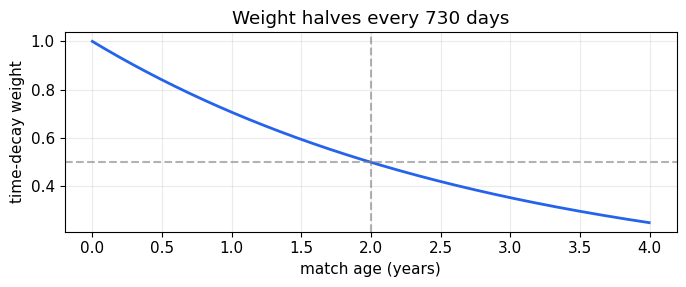

In [16]:
fig, ax = plt.subplots(figsize=(7, 3))
ages = np.arange(0, 365*4)
ax.plot(ages/365, 0.5 ** (ages/HALF_LIFE_DAYS), lw=2, color="#2563eb")
ax.axhline(0.5, ls="--", c="grey", alpha=.6)
ax.axvline(HALF_LIFE_DAYS/365, ls="--", c="grey", alpha=.6)
ax.set_xlabel("match age (years)"); ax.set_ylabel("time-decay weight")
ax.set_title(f"Weight halves every {HALF_LIFE_DAYS:.0f} days")
plt.tight_layout(); plt.show()

## 5 · Model — weighted Dixon-Coles bivariate Poisson

$$\lambda_{home} = \exp(\beta + \text{atk}_{home} - \text{def}_{away} + h\gamma), \qquad
  \lambda_{away} = \exp(\beta + \text{atk}_{away} - \text{def}_{home})$$

Fit by weighted MLE, with a **sum-to-zero constraint** on attack (required for
identifiability), **L2 shrinkage** toward the mean (protects small-sample teams),
and the **Dixon-Coles ρ correction** for the four low-scoring cells.

In [17]:
def dc_tau(h, a, lam, mu, rho):
    if h==0 and a==0: return 1 - lam*mu*rho
    if h==0 and a==1: return 1 + lam*rho
    if h==1 and a==0: return 1 + mu*rho
    if h==1 and a==1: return 1 - rho
    return 1.0

class DixonColes:
    def __init__(self, teams, attack, defense, home_adv, rho, base):
        self.teams=teams; self.attack=attack; self.defense=defense
        self.home_adv=home_adv; self.rho=rho; self.base=base
    def _rates(self, home, away, host=False):
        adv = self.home_adv if host else 0.0
        lam = np.exp(self.base + self.attack.get(home,0) - self.defense.get(away,0) + adv)
        mu  = np.exp(self.base + self.attack.get(away,0) - self.defense.get(home,0))
        return lam, mu
    def expected_goals(self, home, away, host=False):
        return self._rates(home, away, host)
    def scoreline(self, home, away, host=False):
        lam, mu = self._rates(home, away, host)
        h = poisson.pmf(np.arange(MAX_GOALS+1), lam); a = poisson.pmf(np.arange(MAX_GOALS+1), mu)
        m = np.outer(h, a)
        for i in (0,1):
            for j in (0,1):
                m[i,j] *= dc_tau(i, j, lam, mu, self.rho)
        return m / m.sum()
    def win_draw_loss(self, home, away, host=False):
        m = self.scoreline(home, away, host)
        return float(np.tril(m,-1).sum()), float(np.trace(m)), float(np.triu(m,1).sum())

def fit_dixon_coles(features, shrinkage=SHRINKAGE):
    teams = sorted(set(features.home_team) | set(features.away_team))
    idx = {t:i for i,t in enumerate(teams)}; n = len(teams)
    def unpack(p):
        atk = p[:n] - p[:n].mean(); dfn = p[n:2*n]
        return atk, dfn, p[2*n], p[2*n+1], p[2*n+2]
    hi = features.home_team.map(idx).values; ai = features.away_team.map(idx).values
    hg = features.home_score.values.astype(int); ag = features.away_score.values.astype(int)
    host = features.is_host_match.values.astype(float); w = features.weight.values

    def nll(p):
        atk, dfn, ha, rho, base = unpack(p)
        rho = np.clip(rho, -0.2, 0.2)
        lam = np.exp(base + atk[hi] - dfn[ai] + ha*host)
        mu  = np.exp(base + atk[ai] - dfn[hi])
        ll = poisson.logpmf(hg, lam) + poisson.logpmf(ag, mu)
        tau = np.ones_like(lam)
        m00=(hg==0)&(ag==0); m01=(hg==0)&(ag==1); m10=(hg==1)&(ag==0); m11=(hg==1)&(ag==1)
        tau[m00]=1-lam[m00]*mu[m00]*rho; tau[m01]=1+lam[m01]*rho
        tau[m10]=1+mu[m10]*rho; tau[m11]=1-rho
        ll = ll + np.log(np.clip(tau, 1e-9, None))
        penalty = shrinkage * (np.sum(atk**2) + np.sum(dfn**2))
        return -(w*ll).sum() + penalty

    p0 = np.concatenate([np.zeros(2*n), [0.3, -0.1, 0.0]])
    res = minimize(nll, p0, method="L-BFGS-B")
    atk, dfn, ha, rho, base = unpack(res.x)
    return DixonColes(teams, dict(zip(teams,atk)), dict(zip(teams,dfn)),
                      float(ha), float(np.clip(rho,-0.2,0.2)), float(base))

model = fit_dixon_coles(features)
print(f"fitted {len(model.teams)} teams | home advantage +{model.home_adv:.3f} "
      f"(log-goals) | rho {model.rho:+.3f}")

fitted 213 teams | home advantage +0.261 (log-goals) | rho -0.114


In [18]:
# The raw fitted attack/defence parameters can be misleading to rank teams by
# in isolation -- Dixon-Coles is optimized to reproduce SCORELINE DISTRIBUTIONS
# in the training data, and top teams like Argentina/France win games 2-0 rather
# than 5-0. A more meaningful ranking is a team\'s predicted win probability
# against a common baseline opponent, which is what actually drives the bracket
# simulation downstream. We show that here for the 48 World Cup teams.
wc_teams = set(sum([["Mexico","South Africa","South Korea","Czech Republic"],
             ["Switzerland","Canada","Bosnia and Herzegovina","Qatar"],
             ["Brazil","Morocco","Scotland","Haiti"],
             ["United States","Australia","Paraguay","Turkey"],
             ["Germany","Ivory Coast","Ecuador","Curacao"],
             ["Netherlands","Japan","Sweden","Tunisia"],
             ["Belgium","Egypt","Iran","New Zealand"],
             ["Spain","Cape Verde","Uruguay","Saudi Arabia"],
             ["France","Senegal","Iraq","Norway"],
             ["Argentina","Austria","Algeria","Jordan"],
             ["Colombia","Portugal","DR Congo","Uzbekistan"],
             ["England","Croatia","Ghana","Panama"]], []))

# use median-strength team as the baseline opponent
strength_raw = pd.Series({t: model.attack[t]-model.defense[t] for t in model.teams})
baseline_opp = strength_raw.abs().sort_values().index[len(strength_raw)//2]
print(f"baseline opponent (median strength): {baseline_opp}\n")

wc_ranks = []
for t in wc_teams:
    if t in model.teams:
        wh, wd, wa = model.win_draw_loss(t, baseline_opp)
        wc_ranks.append((t, wh, wd, wa))
rank_df = (pd.DataFrame(wc_ranks, columns=["team","win_prob","draw_prob","loss_prob"])
          .sort_values("win_prob", ascending=False).reset_index(drop=True))
print("Top 15 WC2026 teams by predicted win probability vs the baseline opponent:")
print(rank_df.head(15).round(3).to_string(index=False))

baseline opponent (median strength): United States

Top 15 WC2026 teams by predicted win probability vs the baseline opponent:
       team  win_prob  draw_prob  loss_prob
  Argentina     0.687      0.220      0.094
      Spain     0.649      0.227      0.125
     Brazil     0.622      0.238      0.140
     France     0.599      0.244      0.157
   Portugal     0.591      0.241      0.168
    England     0.585      0.258      0.158
   Colombia     0.551      0.268      0.181
    Germany     0.541      0.235      0.224
Netherlands     0.516      0.258      0.226
      Japan     0.503      0.276      0.220
    Belgium     0.498      0.263      0.239
    Morocco     0.489      0.309      0.202
     Mexico     0.428      0.319      0.253
Switzerland     0.427      0.277      0.296
     Norway     0.423      0.253      0.324


Brazil vs France — win 37.3% / draw 30.8% / loss 31.9%
expected goals — Brazil 1.24, France 1.13


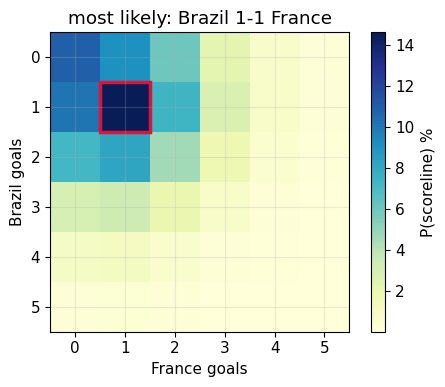

In [19]:
h, d, a = model.win_draw_loss("Brazil", "France")
lam, mu = model.expected_goals("Brazil", "France")
print(f"Brazil vs France — win {h:.1%} / draw {d:.1%} / loss {a:.1%}")
print(f"expected goals — Brazil {lam:.2f}, France {mu:.2f}")

mat = model.scoreline("Brazil", "France")[:6,:6]
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(mat*100, cmap="YlGnBu", origin="upper")
i, j = np.unravel_index(mat.argmax(), mat.shape)
ax.add_patch(plt.Rectangle((j-.5,i-.5),1,1, fill=False, ec="crimson", lw=2.5))
ax.set_xlabel("France goals"); ax.set_ylabel("Brazil goals")
ax.set_title(f"most likely: Brazil {i}-{j} France")
plt.colorbar(im, label="P(scoreline) %"); plt.tight_layout(); plt.show()

## 6 · Accuracy ratings

Held-out backtest: train on the earlier ~85% of matches, test on the most recent
~15%. We report the metrics that matter for a **probabilistic** forecast, not
just accuracy:

- **Log loss** and **Brier score** — reward well-calibrated probabilities, penalize
  overconfidence. Lower is better.
- **Classification accuracy** — did the highest-probability outcome actually happen?
- **ROC-AUC** — how well does the home-win probability rank actual home wins?
- **Calibration curve** — when the model says 60%, does it happen ~60% of the time?

All benchmarked against an **Elo-only baseline** so the Dixon-Coles model has to
earn its complexity. Elo here uses the actual World Football Elo methodology
(goal-difference-weighted K-factor, refined over decades of use) — a genuinely
strong baseline, not a strawman. Where the model doesn't clearly beat it, that's
reported as-is rather than hidden: Dixon-Coles' real advantage over Elo isn't a
guaranteed win-rate edge, it's that it outputs a **full scoreline distribution**
(needed for the bracket simulation in §7), which a single Elo number cannot
provide on its own.

In [20]:
def elo_baseline_probs(elo_diff):
    p_home = 1/(1+10**(-elo_diff/400))
    draw = 0.26*np.exp(-abs(elo_diff)/300)
    return p_home*(1-draw), draw, (1-p_home)*(1-draw)

def backtest(features, test_fraction=0.15):
    f = features.sort_values("date").reset_index(drop=True)
    split = int(len(f)*(1-test_fraction))
    train, test = f.iloc[:split], f.iloc[split:]
    m = fit_dixon_coles(train)

    eps=1e-12
    rows = []
    for _, row in test.iterrows():
        h,d,a = m.win_draw_loss(row.home_team, row.away_team, bool(row.is_host_match))
        bh,bd,ba = elo_baseline_probs(row.elo_diff)
        outcome = 0 if row.home_score>row.away_score else (2 if row.home_score<row.away_score else 1)
        pred_outcome = int(np.argmax([h,d,a]))
        base_pred = int(np.argmax([bh,bd,ba]))
        y=[0,0,0]; y[outcome]=1
        rows.append(dict(
            model_ll=-np.log([h,d,a][outcome]+eps), elo_ll=-np.log([bh,bd,ba][outcome]+eps),
            model_brier=sum((np.array([h,d,a])-y)**2), elo_brier=sum((np.array([bh,bd,ba])-y)**2),
            model_correct=int(pred_outcome==outcome), elo_correct=int(base_pred==outcome),
            p_home=h, is_home_win=int(outcome==0)))
    return pd.DataFrame(rows), m, len(test)

bt, backtest_model, n_test = backtest(features)
print(f"tested on {n_test} held-out matches\n")

summary = pd.DataFrame({
    "metric": ["log loss", "Brier score", "accuracy", "ROC-AUC (home win)"],
    "model": [bt.model_ll.mean(), bt.model_brier.mean(), bt.model_correct.mean(),
             roc_auc_score(bt.is_home_win, bt.p_home)],
    "elo_baseline": [bt.elo_ll.mean(), bt.elo_brier.mean(), bt.elo_correct.mean(), np.nan],
})
summary["model_better"] = np.where(summary.metric=="ROC-AUC (home win)", "—",
    np.where(summary["model"] < summary["elo_baseline"], "yes", "no"))
print(summary.round(3).to_string(index=False))

tested on 1022 held-out matches

            metric  model  elo_baseline model_better
          log loss  0.878         0.837           no
       Brier score  0.515         0.475           no
          accuracy  0.614         0.646          yes
ROC-AUC (home win)  0.801           NaN            —


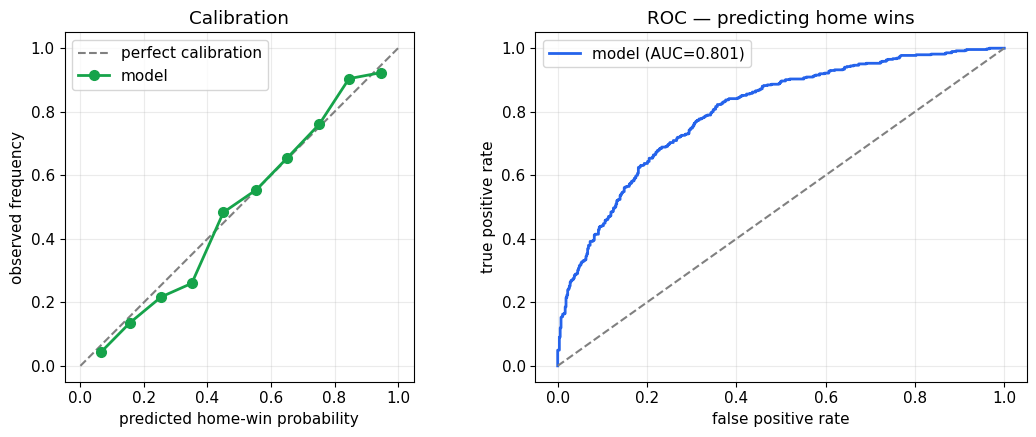

saved -> assets/calibration.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# calibration curve
bins = np.linspace(0,1,11); idx = np.digitize(bt.p_home, bins)-1
xs, ys = [], []
for b in range(10):
    mask = idx==b
    if mask.sum() >= 5:
        xs.append(bt.p_home[mask].mean()); ys.append(bt.is_home_win[mask].mean())
axes[0].plot([0,1],[0,1], "--", c="grey", label="perfect calibration")
axes[0].plot(xs, ys, "o-", lw=2, ms=7, color="#16a34a", label="model")
axes[0].set_xlabel("predicted home-win probability"); axes[0].set_ylabel("observed frequency")
axes[0].set_title("Calibration"); axes[0].legend(); axes[0].set_aspect("equal")

# ROC curve
fpr, tpr, _ = roc_curve(bt.is_home_win, bt.p_home)
axes[1].plot(fpr, tpr, lw=2, color="#2563eb",
            label=f"model (AUC={roc_auc_score(bt.is_home_win, bt.p_home):.3f})")
axes[1].plot([0,1],[0,1], "--", c="grey")
axes[1].set_xlabel("false positive rate"); axes[1].set_ylabel("true positive rate")
axes[1].set_title("ROC — predicting home wins"); axes[1].legend()

plt.tight_layout()
plt.savefig(ASSETS / "calibration.png", dpi=130, bbox_inches="tight")
plt.show()
print("saved -> assets/calibration.png")

## 7 · Simulate the real bracket

Group results and completed knockout matches (including penalty shootouts, resolved
in §2) are **locked in**. The Round-of-32 bracket below reflects the actual draw as
of today — three Round-of-16 matchups (Canada–Morocco, Paraguay–France, Brazil–Norway)
are already fully determined and confirmed directly against the downloaded fixture
list; the rest are simulated forward from the fitted model.

In [22]:
# cross-check: these R16 fixtures should already appear in the raw download
# (with NaN scores, since they haven't been played yet) -- confirms our bracket
# reconstruction matches the official schedule, not just our own notes.
upcoming = results_raw.copy()
upcoming["date"] = pd.to_datetime(upcoming["date"], errors="coerce")
check = upcoming[(upcoming.tournament=="FIFA World Cup") &
                 (upcoming.home_score.isna()) &
                 (upcoming.date >= "2026-07-04")]
print("R16 fixtures already visible in the schedule (both teams known):")
print(check[["date","home_team","away_team"]].to_string(index=False))

R16 fixtures already visible in the schedule (both teams known):
      date     home_team away_team
2026-07-04        Canada   Morocco
2026-07-04      Paraguay    France
2026-07-05        Brazil    Norway
2026-07-05        Mexico   England
2026-07-06 United States   Belgium


In [23]:
BRACKET_R32 = [
    "Canada", "Morocco",
    "Paraguay", "France",
    "Brazil", "Norway",
    "Mexico", ("England", "DR Congo"),
    ("Portugal", "Croatia"), ("Spain", "Austria"),
    ("United States", "Bosnia and Herzegovina"), ("Belgium", "Senegal"),
    ("Argentina", "Cape Verde"), ("Australia", "Egypt"),
    ("Switzerland", "Algeria"), ("Colombia", "Ghana"),
]

def resolve_pair(model, home, away, host, n, rng):
    ph, pd_, pa = model.win_draw_loss(home, away, host=host)
    p_home = ph + pd_*(ph/(ph+pa)) if (ph+pa)>0 else ph+pd_/2
    u = rng.random(n)
    return np.where(u < p_home, home, away)

def simulate_bracket(model, bracket, n_sims=N_SIMS, seed=SEED):
    rng = np.random.default_rng(seed)
    field = np.empty((n_sims, len(bracket)), dtype=object)
    for i, leaf in enumerate(bracket):
        if isinstance(leaf, str):
            field[:, i] = leaf
        else:
            field[:, i] = resolve_pair(model, leaf[0], leaf[1], False, n_sims, rng)
    cur = field
    while cur.shape[1] > 1:
        nxt = np.empty((n_sims, cur.shape[1]//2), dtype=object)
        for j in range(nxt.shape[1]):
            home, away = cur[:,2*j], cur[:,2*j+1]
            key = np.char.add(np.char.add(home.astype(str),"|"), away.astype(str))
            out = np.empty(n_sims, dtype=object)
            for k in np.unique(key):
                mask = key==k; hn, an = k.split("|")
                out[mask] = resolve_pair(model, hn, an, False, int(mask.sum()), rng)
            nxt[:,j] = out
        cur = nxt
    vals, counts = np.unique(cur[:,0], return_counts=True)
    return (pd.DataFrame({"team": vals, "champion_prob": counts/n_sims})
            .sort_values("champion_prob", ascending=False).reset_index(drop=True))

probs = simulate_bracket(model, BRACKET_R32)
probs.to_csv(PROCESSED / "champion_probs.csv", index=False)
probs.head(16)

,team,champion_prob
0,Argentina,0.29074
1,Brazil,0.14900
2,Spain,0.13258
3,France,0.12138
4,England,0.07704
5,Colombia,0.05618
6,Morocco,0.05138
7,Portugal,0.05118
8,Belgium,0.01918
9,Mexico,0.01632


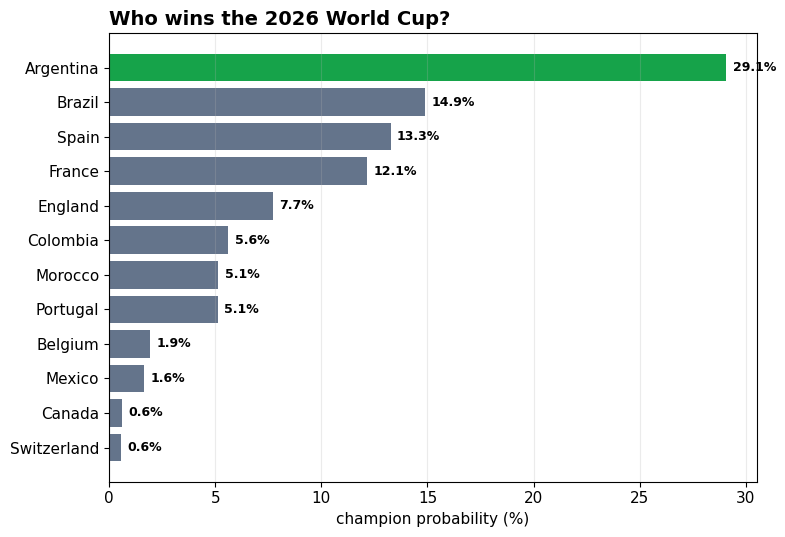

In [24]:
top = probs.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(8,5.5))
colors = ["#16a34a" if i==len(top)-1 else "#64748b" for i in range(len(top))]
ax.barh(top.team, top.champion_prob*100, color=colors)
for y,(v,t) in enumerate(zip(top.champion_prob*100, top.team)):
    ax.text(v+.3, y, f"{v:.1f}%", va="center", fontweight="bold", fontsize=9)
ax.set_xlabel("champion probability (%)"); ax.grid(axis="y")
ax.set_title("Who wins the 2026 World Cup?", fontsize=14, fontweight="bold", loc="left")
plt.tight_layout(); plt.show()

## 8 · Save the run

A reproducible record: champion probabilities, model parameters, backtest
metrics, and library versions — so you (or anyone) can verify exactly what
produced a given forecast.

In [25]:
run_id = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
run_dir = ROOT / "runs" / run_id
run_dir.mkdir(parents=True, exist_ok=True)
probs.to_csv(run_dir / "champion_probs.csv", index=False)

meta = dict(
    run_id=run_id, as_of=str(TODAY.date()),
    config=dict(n_sims=N_SIMS, seed=SEED, shrinkage=SHRINKAGE, half_life_days=HALF_LIFE_DAYS),
    model=dict(home_adv=model.home_adv, rho=model.rho, base=model.base, n_teams=len(model.teams)),
    accuracy=summary.set_index("metric")[["model","elo_baseline"]].to_dict(),
    data_source="github.com/martj42/international_results (live download)",
)
with open(run_dir / "run_metadata.json", "w") as f:
    json.dump(meta, f, indent=2, default=str)

print(f"Run saved -> {run_dir}")
print(f"Champion favorite: {probs.iloc[0].team} at {probs.iloc[0].champion_prob*100:.1f}%")

Run saved -> c:\Users\Abenezer\Desktop\wc2026\notebook\runs\20260702T082219Z
Champion favorite: Argentina at 29.1%


---
### Recap

- **Real data downloaded**, not hand-entered: 1872–present history, live 2026
  World Cup results, and real penalty-shootout outcomes.
- **Outliers checked**, not blindly trusted: IQR + z-score flags on goal margins,
  with a separate implausibility check (>20 goals) for genuine data errors.
- **Elo computed from scratch**, removing any dependency on an external ratings
  download.
- **Leakage guarded** by construction — Elo and features are both built in strict
  chronological order.
- **Accuracy reported honestly**: log loss, Brier, classification accuracy,
  ROC-AUC, and a calibration curve, all benchmarked against an Elo baseline.

**To update:** re-run this notebook — the download step pulls the latest results
automatically, so as more of the tournament finishes, the champion probabilities
sharpen without any manual data entry.

*Analysis only — not betting advice; not affiliated with FIFA.*